# Physiology-Preserving Denoising and Physiology-Constrained VMD Workflow

本 notebook 是对原始实验 notebook 的整理版，目标是服务后续论文写作与可复现实验。

核心流程：

1. 数据读取与结肠段截取
2. 生理保护型预处理降噪
3. 预处理质量评价
4. 半合成 ground-truth 验证
5. 生理约束型 VMD 模态评分
6. Preclean vs Clean VMD 输入对比
7. Mode 1–3 vs Mode 1–2 消融实验
8. K-alpha 参数搜索与最终参数选择
9. 论文图表与结果导出

当前推荐结论：

- VMD 输入：`Pressure_Clean`
- 模态筛选阈值：`min_keep_score = 0.18`
- 后续相空间重构导向参数：`K = 6`, `alpha = 1500`
- 经典对照参数：`K = 5`, `alpha = 2700`

> 注意：`K=3, alpha=1500` 在当前重构误差上最优，但其模态数较少，可能不足以表达后续相空间重构所需的多尺度动力学信息。因此，论文中建议将 `K=6, alpha=1500` 作为 dynamics-oriented main setting，将 `K=3, alpha=1500` 作为 reconstruction-optimal baseline。

In [1]:
# ============================================================
# 0. Environment setup
# ============================================================

import os
import copy
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["axes.unicode_minus"] = False

# 如果系统支持中文字体，可以打开下面这行。
# plt.rcParams['font.sans-serif'] = ['SimHei']

# Project modules
import vmd_utils
import enhanced_vmd_framework
import vmd_mode_scoring

importlib.reload(vmd_utils)
importlib.reload(enhanced_vmd_framework)
importlib.reload(vmd_mode_scoring)

from vmd_utils import physiology_preserving_adaptive_denoise

from enhanced_vmd_framework import (
    recommend_adaptive_parameters,
    make_semisynthetic_pressure_dataset,
    evaluate_semisynthetic_result,
)

from vmd_mode_scoring import (
    physiology_constrained_vmd_reconstruction,
    summarize_physiology_vmd_result,
)

# Output directory
OUTPUT_DIR = Path("./paper_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. User configuration

只需要优先修改这一格。

- `RAW_DATA_PATH`：原始 txt/csv 文件路径。
- `COLON_START_ROW`, `COLON_END_ROW`：结肠段行号范围。
- `PRESSURE_MIN`, `PRESSURE_MAX`：压力硬阈值范围。
- `RESAMPLE_DT`：重采样间隔，目前沿用 1.2 s。

In [2]:
# ============================================================
# 1. User configuration
# ============================================================

RAW_DATA_PATH = r"D:\a_work\课题组实验数据处理\电子胶囊临床实验数据\导出数据\2bHT000007.txt"

# 结肠段行号范围。根据你的当前 notebook，使用 25000:40900。
COLON_START_ROW = 25000
COLON_END_ROW = 40900

TIME_COL = "Time"
PH_COL = "PH"
TEMP_COL = "Temperature"
PRESSURE_COL = "Pressure"

PRESSURE_MIN = 85
PRESSURE_MAX = 130
RESAMPLE_DT = 1.2

# VMD settings
MIN_KEEP_SCORE = 0.18

# 后续相空间重构导向主参数
MAIN_K = 6
MAIN_ALPHA = 1500

# 历史/经典对照参数
REFERENCE_K = 5
REFERENCE_ALPHA = 2700

## 2. Load raw data and extract colon segment

本节只保留一次标准化读取和结肠段截取，删除原 notebook 中重复的绘图和试错单元。

In [3]:
# ============================================================
# 2. Load raw data
# ============================================================

data_raw = pd.read_csv(
    RAW_DATA_PATH,
    delimiter="\t",
    header=0,
    names=[TIME_COL, PH_COL, TEMP_COL, PRESSURE_COL]
).reset_index(drop=True)

for col in [TIME_COL, PH_COL, TEMP_COL, PRESSURE_COL]:
    data_raw[col] = pd.to_numeric(data_raw[col], errors="coerce")

data_raw = data_raw.dropna(
    subset=[TIME_COL, PH_COL, TEMP_COL, PRESSURE_COL]
).reset_index(drop=True)

colon_data = data_raw.iloc[COLON_START_ROW:COLON_END_ROW].copy()
colon_data = colon_data.reset_index(drop=True)

print("Raw data shape:", data_raw.shape)
print("Colon data shape:", colon_data.shape)
colon_data.head()

Raw data shape: (41718, 4)
Colon data shape: (15900, 4)


,Time,PH,Temperature,Pressure
0,39809.23,8.882,36.549,101.123
1,39810.38,8.265,36.430,101.817
2,39811.52,8.333,36.549,101.865
3,39812.66,8.333,36.537,100.901
4,39813.81,9.088,36.430,100.496


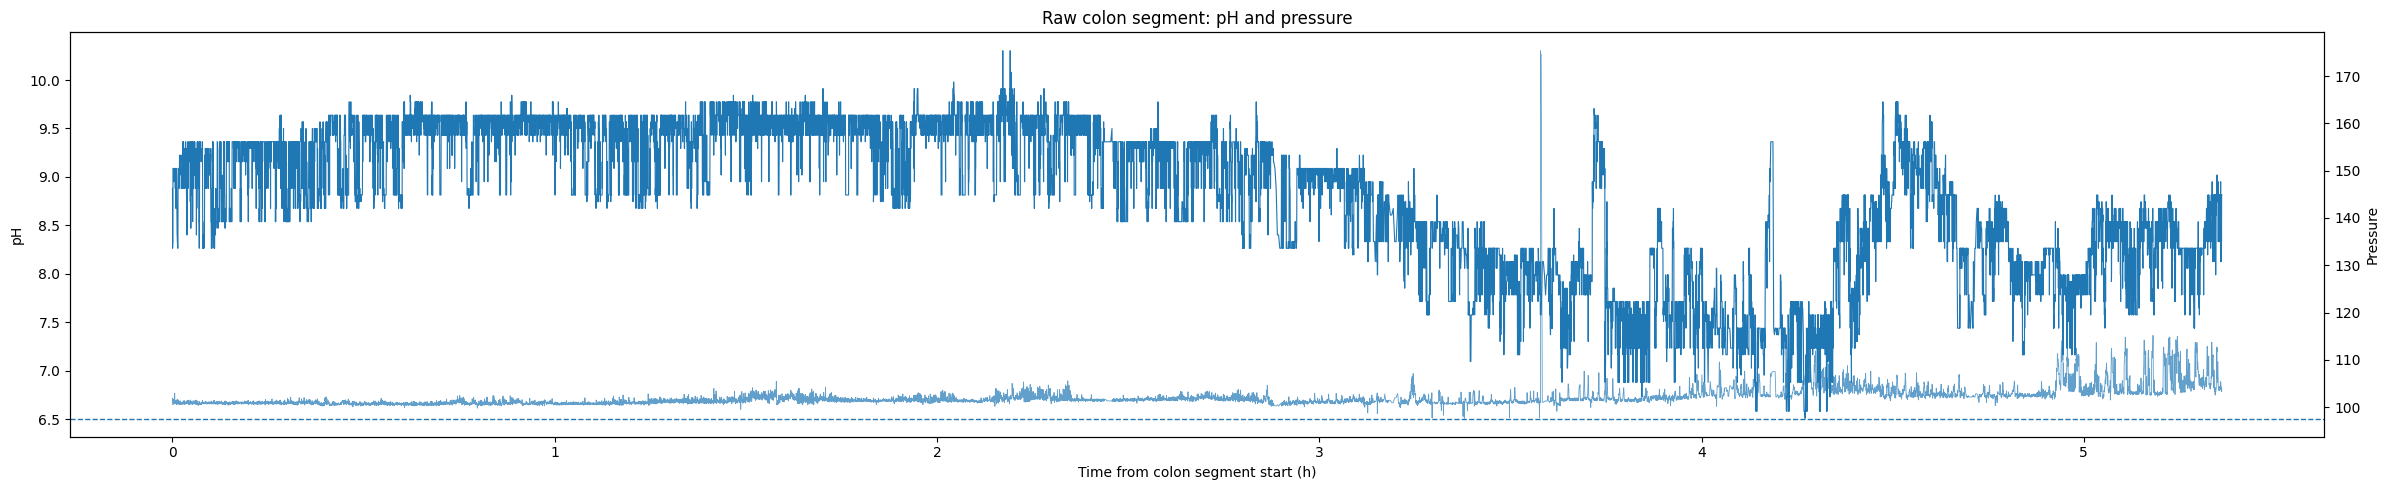

In [4]:
# ============================================================
# 2.1 Quick visualization of colon segment
# ============================================================

time_hours = (colon_data[TIME_COL] - colon_data[TIME_COL].iloc[0]) / 3600.0

fig, ax1 = plt.subplots(figsize=(24, 5))
ax1.plot(time_hours, colon_data[PH_COL], label="pH", linewidth=0.8)
ax1.set_xlabel("Time from colon segment start (h)")
ax1.set_ylabel("pH")
ax1.axhline(y=6.5, linestyle="--", linewidth=1)

ax2 = ax1.twinx()
ax2.plot(time_hours, colon_data[PRESSURE_COL], label="Pressure", linewidth=0.6, alpha=0.7)
ax2.set_ylabel("Pressure")

plt.title("Raw colon segment: pH and pressure")
plt.tight_layout()
plt.show()

## 3. Physiology-preserving adaptive denoising

这里采用信号质量驱动的自适应参数，而不是手动反复调参。

输出核心列：

- `Pressure_Raw`：原始压力
- `Pressure_RangeFixed`：硬阈值修复后压力
- `Pressure_Preclean`：硬阈值 + 伪影修复后压力
- `Pressure_Clean`：事件保护型平滑后的最终压力
- `PhysioEventMask`：生理事件区域
- `ArtifactMask`：伪影区域
- `RangeAbnormalMask`：超出生理压力范围区域

In [5]:
# ============================================================
# 3. Adaptive denoising parameters
# ============================================================

adaptive_result = recommend_adaptive_parameters(
    colon_data,
    time_col=TIME_COL,
    pressure_col=PRESSURE_COL,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
)

allowed_keys = [
    "noise_window_s",
    "event_amp_k",
    "event_area_k",
    "amp_k",
    "slope_k",
    "curvature_k",
    "smooth_window_s",
]

adaptive_kwargs = {
    k: adaptive_result[k]
    for k in allowed_keys
    if k in adaptive_result
}

quality_metrics = {
    k: v for k, v in adaptive_result.items()
    if k not in allowed_keys
}

print("Adaptive denoising parameters:")
print(adaptive_kwargs)

print("\nSignal quality metrics:")
print(quality_metrics)

Adaptive denoising parameters:
{'noise_window_s': 22.233803187973674, 'event_amp_k': 3.1787042550378937, 'event_area_k': 1.6116901593986837, 'amp_k': 6.164929521803949, 'slope_k': 6.164929521803949, 'curvature_k': 6.164929521803949, 'smooth_window_s': 5.470140956392102}

Signal quality metrics:
{'signal_quality_badness': 0.2233803187973673, 'range_abnormal_ratio': 0.0003773584905660377, 'noise_ratio': 0.34192037434718336}


In [6]:
# ============================================================
# 3.1 Run denoising
# ============================================================

df_out = physiology_preserving_adaptive_denoise(
    colon_data,
    time_col=TIME_COL,
    pressure_col=PRESSURE_COL,
    ph_col=PH_COL,
    temp_col=TEMP_COL,
    resample_dt=RESAMPLE_DT,
    use_hard_range_gate=True,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
    **adaptive_kwargs,
)

print("df_out shape:", df_out.shape)
df_out.head()

df_out shape: (16083, 14)


,Time,PH,Temperature,Pressure_Raw,Pressure_RangeFixed,Pressure_Preclean,Pressure_Clean,Baseline,Residual,LocalNoiseSigma,RangeAbnormalMask,ArtifactMask,PhysioEventMask,QualityFlag
0,39809.23,8.882000,36.549000,101.123000,101.123000,101.123000,101.237362,101.102000,0.135362,0.301927,False,False,False,good
1,39810.43,8.267982,36.435219,101.819105,101.819105,101.819105,101.637869,101.070447,0.567422,0.272665,False,False,False,good
2,39811.63,8.333000,36.547842,101.771982,101.771982,101.771982,101.629520,101.098816,0.530705,0.275125,False,False,False,good
3,39812.83,8.444609,36.521183,100.841130,100.841130,100.841130,100.975415,101.064122,-0.088707,0.276055,False,False,False,good
4,39814.03,9.088000,36.434632,100.548105,100.548105,100.548105,100.595274,101.042368,-0.447095,0.261197,False,False,False,good


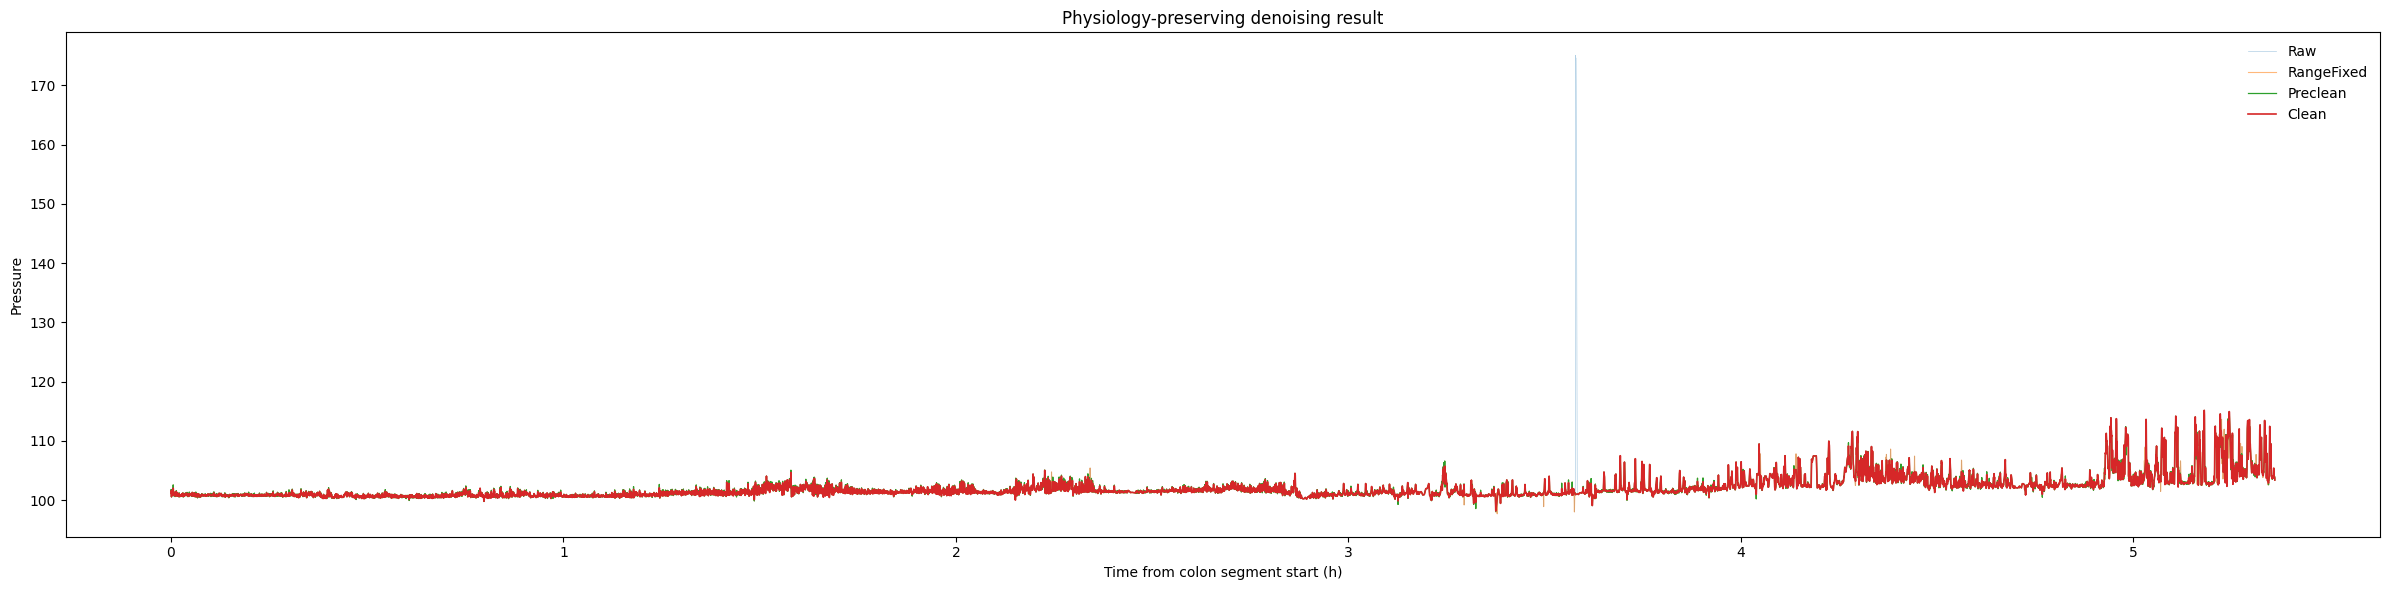

In [7]:
# ============================================================
# 3.2 Visualize denoising result
# ============================================================

time_hours = (df_out["Time"] - df_out["Time"].iloc[0]) / 3600.0

plt.figure(figsize=(24, 6))
plt.plot(time_hours, df_out["Pressure_Raw"], label="Raw", linewidth=0.5, alpha=0.35)
plt.plot(time_hours, df_out["Pressure_RangeFixed"], label="RangeFixed", linewidth=0.8, alpha=0.55)
plt.plot(time_hours, df_out["Pressure_Preclean"], label="Preclean", linewidth=0.9)
plt.plot(time_hours, df_out["Pressure_Clean"], label="Clean", linewidth=1.2)
plt.xlabel("Time from colon segment start (h)")
plt.ylabel("Pressure")
plt.title("Physiology-preserving denoising result")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 4. Preprocessing quality evaluation

保留论文需要的预处理评价：

1. 异常比例 summary
2. 噪声降低 summary
3. Preclean 对 RangeFixed 的生理事件保真
4. Clean 对 Preclean 的生理事件保真

In [8]:
# ============================================================
# 4. Helper functions for preprocessing evaluation
# ============================================================

def get_segments(mask):
    mask = np.asarray(mask, dtype=bool)
    segments = []
    i = 0
    n = len(mask)
    while i < n:
        if not mask[i]:
            i += 1
            continue
        s = i
        while i < n and mask[i]:
            i += 1
        segments.append((s, i))
    return segments


def robust_mad(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    return 1.4826 * np.median(np.abs(x - med))


def first_diff_energy(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan
    return float(np.sum(np.diff(x) ** 2))


def compute_noise_reduction_summary(df_out):
    stable_mask = (
        (~df_out["ArtifactMask"]) &
        (~df_out["PhysioEventMask"]) &
        np.isfinite(df_out["Pressure_Raw"]) &
        np.isfinite(df_out["Pressure_RangeFixed"]) &
        np.isfinite(df_out["Pressure_Preclean"]) &
        np.isfinite(df_out["Pressure_Clean"]) &
        np.isfinite(df_out["Baseline"])
    )

    rows = []
    for name, col in [
        ("Raw", "Pressure_Raw"),
        ("RangeFixed", "Pressure_RangeFixed"),
        ("Preclean", "Pressure_Preclean"),
        ("Clean", "Pressure_Clean"),
    ]:
        x = df_out.loc[stable_mask, col].to_numpy(dtype=float)
        baseline = df_out.loc[stable_mask, "Baseline"].to_numpy(dtype=float)
        residual = x - baseline
        dx = np.diff(x)
        rows.append({
            "Signal": name,
            "Std": np.nanstd(x),
            "Residual_MAD": robust_mad(residual),
            "FirstDiff_MAD": robust_mad(dx),
            "FirstDiffEnergy": first_diff_energy(x),
            "ValidPoints": len(x),
        })

    summary = pd.DataFrame(rows)
    raw_row = summary[summary["Signal"] == "Raw"].iloc[0]

    summary["Residual_MAD_Reduction_%"] = 100 * (
        raw_row["Residual_MAD"] - summary["Residual_MAD"]
    ) / (raw_row["Residual_MAD"] + 1e-9)

    summary["FirstDiff_MAD_Reduction_%"] = 100 * (
        raw_row["FirstDiff_MAD"] - summary["FirstDiff_MAD"]
    ) / (raw_row["FirstDiff_MAD"] + 1e-9)

    summary["FirstDiffEnergy_Reduction_%"] = 100 * (
        raw_row["FirstDiffEnergy"] - summary["FirstDiffEnergy"]
    ) / (raw_row["FirstDiffEnergy"] + 1e-9)

    return summary


def compute_event_preservation_metrics(
    df_out,
    reference_col,
    target_col,
    baseline_col="Baseline",
    event_col="PhysioEventMask",
    artifact_col=None,
    range_col=None,
    max_artifact_ratio=0.10,
    min_points=3,
):
    t = df_out["Time"].to_numpy(dtype=float)
    baseline = df_out[baseline_col].to_numpy(dtype=float)
    ref = df_out[reference_col].to_numpy(dtype=float)
    target = df_out[target_col].to_numpy(dtype=float)
    event_mask = df_out[event_col].to_numpy(dtype=bool)

    artifact_mask = None if artifact_col is None else df_out[artifact_col].to_numpy(dtype=bool)
    range_mask = None if range_col is None else df_out[range_col].to_numpy(dtype=bool)

    rows = []
    for event_id, (s, e) in enumerate(get_segments(event_mask), start=1):
        if e - s < min_points:
            continue

        artifact_ratio = artifact_mask[s:e].mean() if artifact_mask is not None else 0.0
        range_ratio = range_mask[s:e].mean() if range_mask is not None else 0.0

        if artifact_ratio > max_artifact_ratio or range_ratio > max_artifact_ratio:
            continue

        tt = t[s:e]
        bb = baseline[s:e]
        rr = ref[s:e]
        yy = target[s:e]

        valid = np.isfinite(tt) & np.isfinite(bb) & np.isfinite(rr) & np.isfinite(yy)
        if valid.sum() < min_points:
            continue

        tt = tt[valid]
        bb = bb[valid]
        rr = rr[valid]
        yy = yy[valid]

        ref_res = rr - bb
        target_res = yy - bb

        ref_pos = np.maximum(ref_res, 0)
        target_pos = np.maximum(target_res, 0)

        ref_peak = np.max(ref_pos)
        target_peak = np.max(target_pos)
        ref_area = np.trapz(ref_pos, tt)
        target_area = np.trapz(target_pos, tt)

        peak_ratio = target_peak / (ref_peak + 1e-9)
        area_ratio = target_area / (ref_area + 1e-9)

        if np.std(ref_res) > 1e-9 and np.std(target_res) > 1e-9:
            shape_corr = np.corrcoef(ref_res, target_res)[0, 1]
        else:
            shape_corr = np.nan

        rmse = np.sqrt(np.mean((target_res - ref_res) ** 2))
        nrmse = rmse / (np.max(ref_res) - np.min(ref_res) + 1e-9)

        rows.append({
            "EventID": event_id,
            "StartTime": tt[0],
            "EndTime": tt[-1],
            "Duration_s": tt[-1] - tt[0],
            "ReferenceSignal": reference_col,
            "TargetSignal": target_col,
            "Reference_PeakAmplitude": ref_peak,
            "Target_PeakAmplitude": target_peak,
            "PeakPreservationRatio": peak_ratio,
            "Reference_Area": ref_area,
            "Target_Area": target_area,
            "AreaPreservationRatio": area_ratio,
            "ShapeCorrelation": shape_corr,
            "Shape_NRMSE": nrmse,
            "ArtifactRatioInEvent": artifact_ratio,
            "RangeAbnormalRatioInEvent": range_ratio,
        })

    return pd.DataFrame(rows)


def compute_preservation_pass_rate(event_metrics):
    event_metrics = event_metrics.copy()
    peak_ok = event_metrics["PeakPreservationRatio"].between(0.90, 1.10)
    area_ok = event_metrics["AreaPreservationRatio"].between(0.90, 1.10)
    shape_ok = event_metrics["ShapeCorrelation"] >= 0.90
    nrmse_ok = event_metrics["Shape_NRMSE"] <= 0.15

    event_metrics["Peak_OK"] = peak_ok
    event_metrics["Area_OK"] = area_ok
    event_metrics["Shape_OK"] = shape_ok
    event_metrics["NRMSE_OK"] = nrmse_ok
    event_metrics["Overall_Preserved"] = peak_ok & area_ok & shape_ok & nrmse_ok

    summary = pd.DataFrame({
        "Criterion": [
            "Peak ratio within 0.90–1.10",
            "Area ratio within 0.90–1.10",
            "Shape correlation ≥ 0.90",
            "Shape NRMSE ≤ 0.15",
            "All criteria satisfied",
        ],
        "PassedEvents": [
            peak_ok.sum(),
            area_ok.sum(),
            shape_ok.sum(),
            nrmse_ok.sum(),
            event_metrics["Overall_Preserved"].sum(),
        ],
        "TotalEvents": [len(event_metrics)] * 5,
        "PassRate": [
            peak_ok.mean(),
            area_ok.mean(),
            shape_ok.mean(),
            nrmse_ok.mean(),
            event_metrics["Overall_Preserved"].mean(),
        ],
    })
    return summary, event_metrics

In [9]:
# ============================================================
# 4.1 Preprocessing summary tables
# ============================================================

preprocessing_summary = pd.DataFrame({
    "Metric": [
        "Signal length",
        "Range abnormal count",
        "Range abnormal ratio",
        "Artifact count",
        "Artifact ratio",
        "PhysioEvent count",
        "PhysioEvent ratio",
    ],
    "Value": [
        len(df_out),
        df_out["RangeAbnormalMask"].sum(),
        df_out["RangeAbnormalMask"].mean(),
        df_out["ArtifactMask"].sum(),
        df_out["ArtifactMask"].mean(),
        df_out["PhysioEventMask"].sum(),
        df_out["PhysioEventMask"].mean(),
    ],
})

noise_reduction_summary = compute_noise_reduction_summary(df_out)

preclean_event_metrics = compute_event_preservation_metrics(
    df_out,
    reference_col="Pressure_RangeFixed",
    target_col="Pressure_Preclean",
    artifact_col="ArtifactMask",
    range_col="RangeAbnormalMask",
)

clean_event_metrics = compute_event_preservation_metrics(
    df_out,
    reference_col="Pressure_Preclean",
    target_col="Pressure_Clean",
)

preclean_pass_summary, preclean_event_metrics_checked = compute_preservation_pass_rate(preclean_event_metrics)
clean_pass_summary, clean_event_metrics_checked = compute_preservation_pass_rate(clean_event_metrics)

print("Preprocessing summary")
display(preprocessing_summary)

print("Noise reduction summary")
display(noise_reduction_summary)

print("Preclean event preservation summary")
display(preclean_event_metrics[["PeakPreservationRatio", "AreaPreservationRatio", "ShapeCorrelation", "Shape_NRMSE"]].describe())

print("Clean event preservation summary")
display(clean_event_metrics[["PeakPreservationRatio", "AreaPreservationRatio", "ShapeCorrelation", "Shape_NRMSE"]].describe())

Preprocessing summary


,Metric,Value
0,Signal length,16083.000000
1,Range abnormal count,6.000000
2,Range abnormal ratio,0.000373
3,Artifact count,157.000000
4,Artifact ratio,0.009762
5,PhysioEvent count,784.000000
6,PhysioEvent ratio,0.048747


Noise reduction summary


,Signal,Std,Residual_MAD,FirstDiff_MAD,FirstDiffEnergy,ValidPoints,Residual_MAD_Reduction_%,FirstDiff_MAD_Reduction_%,FirstDiffEnergy_Reduction_%
0,Raw,1.561257,0.276095,0.237230,5378.893205,15165,0.000000,0.000000,0.000000
1,RangeFixed,1.324532,0.275842,0.236832,2734.154407,15165,0.091780,0.167502,49.168829
2,Preclean,1.324885,0.276245,0.236991,2762.927436,15165,-0.054486,0.100726,48.633904
3,Clean,1.314501,0.252236,0.162456,1823.096989,15165,8.641724,31.519679,66.106466


Preclean event preservation summary


,PeakPreservationRatio,AreaPreservationRatio,ShapeCorrelation,Shape_NRMSE
count,7.200000e+01,72.000000,72.000000,72.000000
mean,1.000000e+00,1.000486,0.998470,0.005381
std,2.823598e-10,0.004720,0.008842,0.029660
min,1.000000e+00,0.990061,0.943849,0.000000
25%,1.000000e+00,1.000000,1.000000,0.000000
50%,1.000000e+00,1.000000,1.000000,0.000000
75%,1.000000e+00,1.000000,1.000000,0.000000
max,1.000000e+00,1.038132,1.000000,0.184936


Clean event preservation summary


,PeakPreservationRatio,AreaPreservationRatio,ShapeCorrelation,Shape_NRMSE
count,8.200000e+01,82.000000,82.000000,82.000000
mean,1.000000e+00,1.000440,0.999920,0.002562
std,2.721183e-10,0.002179,0.000232,0.005394
min,1.000000e+00,0.988095,0.998660,0.000000
25%,1.000000e+00,1.000000,0.999987,0.000000
50%,1.000000e+00,1.000000,1.000000,0.000000
75%,1.000000e+00,1.000175,1.000000,0.002232
max,1.000000e+00,1.010844,1.000000,0.026399


## 5. Semi-synthetic validation

半合成实验用于解决真实医学信号缺少 clean ground truth 的问题。

流程：

1. 从 `df_out` 构造 pseudo-clean reference。
2. 人工注入已知位置伪影。
3. 重新运行预处理算法。
4. 与 truth 比较 RMSE、Correlation、Artifact F1、Event IoU 等指标。

In [10]:
# ============================================================
# 5. Semi-synthetic benchmark
# ============================================================

# 重要修正：df_out 中没有名为 "Pressure" 的列。
# 半合成验证需要一个标准输入列 "Pressure"，因此先构造 semi_source。
# 这里用 Pressure_Clean 作为 pseudo-clean reference，再人工注入伪影。
semi_source = df_out[["Time", "PH", "Temperature", "Baseline", "PhysioEventMask"]].copy()
semi_source["Pressure"] = df_out["Pressure_Clean"].values

semi_df, truth = make_semisynthetic_pressure_dataset(
    semi_source,
    time_col="Time",
    pressure_col="Pressure",
    ph_col="PH",
    temp_col="Temperature",
    event_col="PhysioEventMask",
)

adaptive_result_semi = recommend_adaptive_parameters(
    semi_df,
    time_col="Time",
    pressure_col="Pressure",
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
)

adaptive_kwargs_semi = {
    k: adaptive_result_semi[k]
    for k in allowed_keys
    if k in adaptive_result_semi
}

semi_pred_df = physiology_preserving_adaptive_denoise(
    semi_df,
    time_col="Time",
    pressure_col="Pressure",
    ph_col="PH",
    temp_col="Temperature",
    resample_dt=RESAMPLE_DT,
    use_hard_range_gate=True,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
    **adaptive_kwargs_semi,
)

semi_report = evaluate_semisynthetic_result(
    semi_pred_df,
    truth,
    time_col="Time",
    clean_col="Pressure_Clean",
    artifact_col="ArtifactMask",
    event_col="PhysioEventMask",
)

semi_report["summary"]

,RMSE,Correlation,Artifact_F1,Artifact_Recall,Mean_Event_IoU,Mean_Abs_OnsetError_s,Mean_Abs_OffsetError_s
0,0.17997,0.995126,0.460641,0.470238,0.672952,2.758442,2.275325


## 6. VMD helper functions

本节放 VMD 参数搜索、重构评价、事件保真评价的统一函数，避免后面重复写代码。

In [11]:
# ============================================================
# 6. VMD evaluation helper functions
# ============================================================

def align_arrays(*arrays):
    n = min(len(a) for a in arrays)
    return [np.asarray(a)[:n] for a in arrays]


def baseline_align_reconstruction(reference, reconstructed):
    reference = np.asarray(reference, dtype=float)
    reconstructed = np.asarray(reconstructed, dtype=float)
    n = min(len(reference), len(reconstructed))
    reference = reference[:n]
    reconstructed = reconstructed[:n]
    reconstructed = reconstructed - np.nanmean(reconstructed) + np.nanmean(reference)
    return reference, reconstructed


def compute_reconstruction_metrics(reference, reconstructed):
    reference, reconstructed = baseline_align_reconstruction(reference, reconstructed)
    valid = np.isfinite(reference) & np.isfinite(reconstructed)
    ref = reference[valid]
    rec = reconstructed[valid]
    rmse = np.sqrt(np.mean((rec - ref) ** 2))
    corr = np.corrcoef(ref, rec)[0, 1] if np.std(ref) > 1e-9 and np.std(rec) > 1e-9 else np.nan
    return {"RMSE": rmse, "Correlation": corr}


def compute_event_fidelity_metrics(time, reference, reconstructed, event_mask, baseline, min_points=3):
    time, reference, reconstructed, event_mask, baseline = align_arrays(
        time, reference, reconstructed, event_mask, baseline
    )
    time = time.astype(float)
    reference = reference.astype(float)
    reconstructed = reconstructed.astype(float)
    event_mask = event_mask.astype(bool)
    baseline = baseline.astype(float)

    # 补均值，避免 VMD 重构基线偏移影响事件幅值
    _, reconstructed = baseline_align_reconstruction(reference, reconstructed)

    rows = []
    for event_id, (s, e) in enumerate(get_segments(event_mask), start=1):
        if e - s < min_points:
            continue

        tt = time[s:e]
        ref = reference[s:e]
        rec = reconstructed[s:e]
        base = baseline[s:e]

        valid = np.isfinite(tt) & np.isfinite(ref) & np.isfinite(rec) & np.isfinite(base)
        if valid.sum() < min_points:
            continue

        tt = tt[valid]
        ref = ref[valid]
        rec = rec[valid]
        base = base[valid]

        ref_res = ref - base
        rec_res = rec - base
        ref_pos = np.maximum(ref_res, 0)
        rec_pos = np.maximum(rec_res, 0)

        ref_peak = np.max(ref_pos)
        rec_peak = np.max(rec_pos)
        ref_area = np.trapz(ref_pos, tt)
        rec_area = np.trapz(rec_pos, tt)

        peak_ratio = rec_peak / (ref_peak + 1e-9)
        area_ratio = rec_area / (ref_area + 1e-9)

        ref_event = ref_pos > 0.05 * (ref_peak + 1e-9)
        rec_event = rec_pos > 0.05 * (ref_peak + 1e-9)
        intersection = np.logical_and(ref_event, rec_event).sum()
        union = np.logical_or(ref_event, rec_event).sum()
        event_iou = intersection / (union + 1e-9)

        rows.append({
            "EventID": event_id,
            "PeakPreservationRatio": peak_ratio,
            "AreaPreservationRatio": area_ratio,
            "Event_IoU": event_iou,
        })

    event_df = pd.DataFrame(rows)
    summary = {
        "Mean_Event_IoU": event_df["Event_IoU"].mean() if len(event_df) else np.nan,
        "Mean_PeakPreservationRatio": event_df["PeakPreservationRatio"].mean() if len(event_df) else np.nan,
        "Mean_AreaPreservationRatio": event_df["AreaPreservationRatio"].mean() if len(event_df) else np.nan,
        "NumEvents": len(event_df),
    }
    return summary, event_df


def reconstruct_from_selected_modes(vmd_result, reference_signal, selected_mode_numbers):
    selected_idx = [m - 1 for m in selected_mode_numbers]
    modes = np.asarray(vmd_result.modes, dtype=float)
    reference_signal = np.asarray(reference_signal, dtype=float)
    n = min(modes.shape[1], len(reference_signal))
    modes = modes[:, :n]
    reference_signal = reference_signal[:n]
    reconstructed = np.sum(modes[selected_idx, :], axis=0)
    reconstructed = reconstructed - np.nanmean(reconstructed) + np.nanmean(reference_signal)
    return reconstructed


def evaluate_single_vmd_setting(signal, time, event_mask, artifact_mask, baseline, K, alpha, min_keep_score=0.18):
    vmd_res = physiology_constrained_vmd_reconstruction(
        signal=signal,
        time=time,
        event_mask=event_mask,
        artifact_mask=artifact_mask,
        K=K,
        alpha=alpha,
        min_keep_score=min_keep_score,
    )

    reconstructed = vmd_res.reconstructed
    metrics = compute_reconstruction_metrics(signal, reconstructed)
    event_summary, _ = compute_event_fidelity_metrics(
        time=time,
        reference=signal,
        reconstructed=reconstructed,
        event_mask=event_mask,
        baseline=baseline,
    )

    mode_summary = summarize_physiology_vmd_result(vmd_res)
    selected_modes = mode_summary.loc[mode_summary["Selected"], "Mode"].tolist()

    signal_arr = np.asarray(signal, dtype=float)
    signal_range = np.nanmax(signal_arr) - np.nanmin(signal_arr) + 1e-9
    rmse_norm = metrics["RMSE"] / signal_range

    peak_error = abs(event_summary["Mean_PeakPreservationRatio"] - 1.0)
    area_error = abs(event_summary["Mean_AreaPreservationRatio"] - 1.0)

    objective_score = (
        0.25 * (1.0 - rmse_norm)
        + 0.25 * metrics["Correlation"]
        + 0.20 * event_summary["Mean_Event_IoU"]
        + 0.15 * (1.0 - peak_error)
        + 0.15 * (1.0 - area_error)
    )

    return {
        "K": K,
        "alpha": alpha,
        "min_keep_score": min_keep_score,
        "RMSE": metrics["RMSE"],
        "RMSE_Norm": rmse_norm,
        "Correlation": metrics["Correlation"],
        "Mean_Event_IoU": event_summary["Mean_Event_IoU"],
        "Mean_PeakPreservationRatio": event_summary["Mean_PeakPreservationRatio"],
        "Mean_AreaPreservationRatio": event_summary["Mean_AreaPreservationRatio"],
        "NumEvents": event_summary["NumEvents"],
        "NumSelectedModes": len(selected_modes),
        "SelectedModes": selected_modes,
        "ObjectiveScore": objective_score,
    }


def search_best_vmd_parameters(pred_df, signal_col="Pressure_Clean", K_list=None, alpha_list=None, min_keep_score=0.18):
    if K_list is None:
        K_list = [3, 4, 5, 6, 7]
    if alpha_list is None:
        alpha_list = [1500, 2000, 2500, 2700, 3000, 3500]

    signal = pred_df[signal_col].values
    time = pred_df["Time"].values
    event_mask = pred_df["PhysioEventMask"].values
    artifact_mask = pred_df["ArtifactMask"].values
    baseline = pred_df["Baseline"].values

    rows = []
    for K in K_list:
        for alpha in alpha_list:
            try:
                result = evaluate_single_vmd_setting(
                    signal=signal,
                    time=time,
                    event_mask=event_mask,
                    artifact_mask=artifact_mask,
                    baseline=baseline,
                    K=K,
                    alpha=alpha,
                    min_keep_score=min_keep_score,
                )
                rows.append(result)
                print(
                    f"Done: K={K}, alpha={alpha}, "
                    f"Score={result['ObjectiveScore']:.4f}, "
                    f"RMSE={result['RMSE']:.4f}, "
                    f"Corr={result['Correlation']:.4f}, "
                    f"Modes={result['SelectedModes']}"
                )
            except Exception as e:
                print(f"Failed: K={K}, alpha={alpha}, error={e}")

    result_df = pd.DataFrame(rows)
    return result_df.sort_values("ObjectiveScore", ascending=False).reset_index(drop=True)

## 7. VMD input comparison: Preclean vs Clean

目的：比较 `Pressure_Preclean` 和 `Pressure_Clean` 哪个更适合作为 VMD 输入。

本节基于原始真实结肠段预处理结果 `df_out` 进行比较。当前已有实验结论：`Pressure_Clean` 获得更低 RMSE 和更高相关性，同时事件保留指标与 `Pressure_Preclean` 基本一致。

论文表达：

**English:** Although `Pressure_Clean` underwent adaptive smoothing, its physiological event preservation metrics remained comparable to those of `Pressure_Preclean`, while achieving improved VMD reconstruction fidelity.

**中文：** 尽管 `Pressure_Clean` 经历了自适应平滑处理，但其生理事件保留指标与 `Pressure_Preclean` 基本一致，同时获得了更好的 VMD 重构性能。

In [12]:
# ============================================================
# 7. Preclean vs Clean as VMD input
# ============================================================

vmd_preclean = physiology_constrained_vmd_reconstruction(
    signal=df_out["Pressure_Preclean"].values,
    time=df_out["Time"].values,
    event_mask=df_out["PhysioEventMask"].values,
    artifact_mask=df_out["ArtifactMask"].values,
    K=REFERENCE_K,
    alpha=REFERENCE_ALPHA,
    min_keep_score=MIN_KEEP_SCORE,
)

vmd_clean = physiology_constrained_vmd_reconstruction(
    signal=df_out["Pressure_Clean"].values,
    time=df_out["Time"].values,
    event_mask=df_out["PhysioEventMask"].values,
    artifact_mask=df_out["ArtifactMask"].values,
    K=REFERENCE_K,
    alpha=REFERENCE_ALPHA,
    min_keep_score=MIN_KEEP_SCORE,
)

summary_preclean = summarize_physiology_vmd_result(vmd_preclean)
summary_clean = summarize_physiology_vmd_result(vmd_clean)

summary_preclean["InputSignal"] = "Pressure_Preclean"
summary_clean["InputSignal"] = "Pressure_Clean"

vmd_input_mode_comparison = pd.concat([summary_preclean, summary_clean], ignore_index=True)

metric_preclean = compute_reconstruction_metrics(df_out["Pressure_Preclean"].values, vmd_preclean.reconstructed)
metric_clean = compute_reconstruction_metrics(df_out["Pressure_Clean"].values, vmd_clean.reconstructed)

vmd_input_reconstruction_comparison = pd.DataFrame([
    {"InputSignal": "Pressure_Preclean", **metric_preclean},
    {"InputSignal": "Pressure_Clean", **metric_clean},
])

summary_preclean_event, _ = compute_event_fidelity_metrics(
    time=df_out["Time"].values,
    reference=df_out["Pressure_Preclean"].values,
    reconstructed=vmd_preclean.reconstructed,
    event_mask=df_out["PhysioEventMask"].values,
    baseline=df_out["Baseline"].values,
)

summary_clean_event, _ = compute_event_fidelity_metrics(
    time=df_out["Time"].values,
    reference=df_out["Pressure_Clean"].values,
    reconstructed=vmd_clean.reconstructed,
    event_mask=df_out["PhysioEventMask"].values,
    baseline=df_out["Baseline"].values,
)

vmd_input_event_comparison = pd.DataFrame([
    {"InputSignal": "Pressure_Preclean", **summary_preclean_event},
    {"InputSignal": "Pressure_Clean", **summary_clean_event},
])

print("VMD mode comparison")
display(vmd_input_mode_comparison)

print("VMD reconstruction comparison")
display(vmd_input_reconstruction_comparison)

print("VMD event preservation comparison")
display(vmd_input_event_comparison)

VMD mode comparison


,Mode,DominantFreq_Hz,EnergyRatio,SignalCorrelation,EventCorrelation,EventEnergyRatio,ArtifactEnergyRatio,SpectralEntropy,Kurtosis,TemporalContinuity,PhysioKeepScore,Selected,InputSignal
0,1,0.000052,0.705808,0.874531,0.498804,0.204300,0.062060,0.310803,6.694342,0.999829,0.478185,True,Pressure_Preclean
1,2,0.021971,0.093619,0.421495,0.737724,0.422052,0.060814,0.628837,17.548982,0.978259,0.369206,True,Pressure_Preclean
2,3,0.048657,0.024048,0.255727,0.435780,0.323871,0.053257,0.667362,16.919079,0.885265,0.222662,True,Pressure_Preclean
3,4,0.087727,0.019480,0.209127,0.375043,0.250987,0.053458,0.661281,17.459520,0.717207,0.151181,False,Pressure_Preclean
4,5,0.113325,0.009066,0.161320,0.295871,0.168422,0.035888,0.683626,13.204050,0.586063,0.119919,False,Pressure_Preclean
5,1,0.000052,0.711418,0.877961,0.491689,0.204167,0.062044,0.310682,6.691322,0.999830,0.477079,True,Pressure_Clean
6,2,0.021971,0.094347,0.423241,0.734219,0.421614,0.060790,0.628540,17.512987,0.978384,0.372017,True,Pressure_Clean
7,3,0.048657,0.024129,0.256788,0.436913,0.325043,0.052876,0.667056,16.754098,0.887012,0.228320,True,Pressure_Clean
8,4,0.087727,0.018992,0.208007,0.371302,0.256123,0.053748,0.661719,18.023237,0.720847,0.150864,False,Pressure_Clean
9,5,0.113325,0.008927,0.158798,0.305702,0.176531,0.038808,0.680921,14.400127,0.593371,0.117109,False,Pressure_Clean


VMD reconstruction comparison


,InputSignal,RMSE,Correlation
0,Pressure_Preclean,0.481700,0.966184
1,Pressure_Clean,0.454133,0.969827


VMD event preservation comparison


,InputSignal,Mean_Event_IoU,Mean_PeakPreservationRatio,Mean_AreaPreservationRatio,NumEvents
0,Pressure_Preclean,0.990895,0.685567,0.783719,82
1,Pressure_Clean,0.990895,0.685038,0.783787,82


## 8. Mode ablation: Mode 1–3 vs Mode 1–2

目的：验证 Mode 3 是否可以删除。

当前已有实验结论：Mode 3 不能删除。虽然它的 `PhysioKeepScore` 中等，但它携带重要事件峰值和面积信息。

In [13]:
# ============================================================
# 8. Mode ablation experiment
# ============================================================

# 这里以 Clean 输入、reference K/alpha 为例。
# 如果要用主参数 K=6, alpha=1500，也可以将 vmd_clean 换成后面 main_vmd_result。

reference_signal = df_out["Pressure_Clean"].values

recon_A = reconstruct_from_selected_modes(
    vmd_clean,
    reference_signal=reference_signal,
    selected_mode_numbers=[1, 2, 3],
)

recon_B = reconstruct_from_selected_modes(
    vmd_clean,
    reference_signal=reference_signal,
    selected_mode_numbers=[1, 2],
)

metrics_A = compute_reconstruction_metrics(reference_signal, recon_A)
metrics_B = compute_reconstruction_metrics(reference_signal, recon_B)

summary_A, event_A = compute_event_fidelity_metrics(
    time=df_out["Time"].values,
    reference=reference_signal,
    reconstructed=recon_A,
    event_mask=df_out["PhysioEventMask"].values,
    baseline=df_out["Baseline"].values,
)

summary_B, event_B = compute_event_fidelity_metrics(
    time=df_out["Time"].values,
    reference=reference_signal,
    reconstructed=recon_B,
    event_mask=df_out["PhysioEventMask"].values,
    baseline=df_out["Baseline"].values,
)

mode_ablation_comparison = pd.DataFrame([
    {
        "Scheme": "A",
        "SelectedModes": "Mode 1–3",
        **metrics_A,
        **summary_A,
    },
    {
        "Scheme": "B",
        "SelectedModes": "Mode 1–2",
        **metrics_B,
        **summary_B,
    },
])

mode_ablation_comparison

,Scheme,SelectedModes,RMSE,Correlation,Mean_Event_IoU,Mean_PeakPreservationRatio,Mean_AreaPreservationRatio,NumEvents
0,A,Mode 1–3,0.454133,0.969827,0.990895,0.685038,0.783787,82
1,B,Mode 1–2,0.586600,0.948788,0.985668,0.519475,0.612979,82


## 9. K-alpha parameter search

目的：避免直接声称 `K=5, alpha=2700` 是“最优”。

当前实验结果显示：

- `K=3, alpha=1500` 是 reconstruction-optimal baseline；
- `K=6, alpha=1500` 在重构质量、事件面积保留和多尺度模态丰富性之间更平衡；
- 对于后续相空间重构和疾病分类，建议采用 `K=6, alpha=1500` 作为主参数。

In [14]:
# ============================================================
# 9. Parameter search
# ============================================================

K_list = [3, 4, 5, 6, 7]
alpha_list = [1500, 2000, 2500, 2700, 3000, 3500]

vmd_param_search_result = search_best_vmd_parameters(
    pred_df=df_out,
    signal_col="Pressure_Clean",
    K_list=K_list,
    alpha_list=alpha_list,
    min_keep_score=MIN_KEEP_SCORE,
)

vmd_param_search_result.head(10)

Done: K=3, alpha=1500, Score=0.9388, RMSE=0.2812, Corr=0.9889, Modes=[1, 2, 3]
Done: K=3, alpha=2000, Score=0.9289, RMSE=0.3129, Corr=0.9862, Modes=[1, 2, 3]
Done: K=3, alpha=2500, Score=0.8729, RMSE=0.5226, Corr=0.9597, Modes=[1, 2]
Done: K=3, alpha=2700, Score=0.8706, RMSE=0.5268, Corr=0.9591, Modes=[1, 2]
Done: K=3, alpha=3000, Score=0.8677, RMSE=0.5327, Corr=0.9582, Modes=[1, 2]
Done: K=3, alpha=3500, Score=0.8631, RMSE=0.5418, Corr=0.9568, Modes=[1, 2]
Done: K=4, alpha=1500, Score=0.9224, RMSE=0.4114, Corr=0.9752, Modes=[1, 2, 3]
Done: K=4, alpha=2000, Score=0.9163, RMSE=0.4236, Corr=0.9738, Modes=[1, 2, 3]
Done: K=4, alpha=2500, Score=0.9108, RMSE=0.4340, Corr=0.9725, Modes=[1, 2, 3]
Done: K=4, alpha=2700, Score=0.9089, RMSE=0.4378, Corr=0.9721, Modes=[1, 2, 3]
Done: K=4, alpha=3000, Score=0.9061, RMSE=0.4433, Corr=0.9714, Modes=[1, 2, 3]
Done: K=4, alpha=3500, Score=0.9015, RMSE=0.4520, Corr=0.9703, Modes=[1, 2, 3]
Done: K=5, alpha=1500, Score=0.9163, RMSE=0.4346, Corr=0.9722, M

,K,alpha,min_keep_score,RMSE,RMSE_Norm,Correlation,Mean_Event_IoU,Mean_PeakPreservationRatio,Mean_AreaPreservationRatio,NumEvents,NumSelectedModes,SelectedModes,ObjectiveScore
0,3,1500,0.18,0.281179,0.016574,0.988883,0.994422,0.791107,0.854813,82,3,"[1, 2, 3]",0.938850
1,3,2000,0.18,0.312942,0.018446,0.986238,0.994422,0.761540,0.825853,82,3,"[1, 2, 3]",0.928941
2,6,1500,0.18,0.416491,0.024550,0.974380,0.992704,0.753933,0.858780,82,4,"[1, 2, 3, 4]",0.927905
3,7,1500,0.18,0.426799,0.025157,0.973065,0.992704,0.746466,0.851886,82,4,"[1, 2, 3, 4]",0.925271
4,6,2000,0.18,0.423158,0.024943,0.973568,0.992704,0.742935,0.847796,82,4,"[1, 2, 3, 4]",0.924307
5,4,1500,0.18,0.411407,0.024250,0.975194,0.991833,0.738541,0.836837,82,3,"[1, 2, 3]",0.922409
6,7,2000,0.18,0.431213,0.025417,0.972526,0.992704,0.737347,0.842427,82,4,"[1, 2, 3, 4]",0.922284
7,6,2500,0.18,0.428638,0.025266,0.972898,0.992704,0.733643,0.838150,82,4,"[1, 2, 3, 4]",0.921218
8,6,2700,0.18,0.430648,0.025384,0.972651,0.992704,0.730238,0.834537,82,4,"[1, 2, 3, 4]",0.920074
9,7,2500,0.18,0.435407,0.025664,0.972011,0.992704,0.729035,0.833609,82,4,"[1, 2, 3, 4]",0.919524


In [15]:
# ============================================================
# 9.1 Select final settings for paper
# ============================================================

reconstruction_optimal = vmd_param_search_result.iloc[0]

dynamics_oriented = vmd_param_search_result[
    (vmd_param_search_result["K"] == MAIN_K)
    & (vmd_param_search_result["alpha"] == MAIN_ALPHA)
].iloc[0]

reference_legacy = vmd_param_search_result[
    (vmd_param_search_result["K"] == REFERENCE_K)
    & (vmd_param_search_result["alpha"] == REFERENCE_ALPHA)
].iloc[0]

selected_parameter_summary = pd.DataFrame([
    {"Role": "Reconstruction-optimal baseline", **reconstruction_optimal.to_dict()},
    {"Role": "Dynamics-oriented main setting", **dynamics_oriented.to_dict()},
    {"Role": "Legacy/reference setting", **reference_legacy.to_dict()},
])

selected_parameter_summary

,Role,K,alpha,min_keep_score,RMSE,RMSE_Norm,Correlation,Mean_Event_IoU,Mean_PeakPreservationRatio,Mean_AreaPreservationRatio,NumEvents,NumSelectedModes,SelectedModes,ObjectiveScore
0,Reconstruction-optimal baseline,3,1500,0.18,0.281179,0.016574,0.988883,0.994422,0.791107,0.854813,82,3,"[1, 2, 3]",0.938850
1,Dynamics-oriented main setting,6,1500,0.18,0.416491,0.024550,0.974380,0.992704,0.753933,0.858780,82,4,"[1, 2, 3, 4]",0.927905
2,Legacy/reference setting,5,2700,0.18,0.454133,0.026768,0.969827,0.990895,0.685038,0.783787,82,3,"[1, 2, 3]",0.904267


## 10. Final VMD decomposition using dynamics-oriented setting

最终用于后续相空间重构的 VMD 结果建议来自：

- input signal: `Pressure_Clean`
- `K = 6`
- `alpha = 1500`
- `min_keep_score = 0.18`

In [16]:
# ============================================================
# 10. Final VMD decomposition for downstream phase-space analysis
# ============================================================

main_vmd_result = physiology_constrained_vmd_reconstruction(
    signal=df_out["Pressure_Clean"].values,
    time=df_out["Time"].values,
    event_mask=df_out["PhysioEventMask"].values,
    artifact_mask=df_out["ArtifactMask"].values,
    K=MAIN_K,
    alpha=MAIN_ALPHA,
    min_keep_score=MIN_KEEP_SCORE,
)

main_mode_summary = summarize_physiology_vmd_result(main_vmd_result)
main_mode_summary

,Mode,DominantFreq_Hz,EnergyRatio,SignalCorrelation,EventCorrelation,EventEnergyRatio,ArtifactEnergyRatio,SpectralEntropy,Kurtosis,TemporalContinuity,PhysioKeepScore,Selected
0,1,0.000052,0.673092,0.848852,0.514512,0.163006,0.057705,0.280577,5.815895,0.999947,0.472361,True
1,2,0.010571,0.082721,0.400900,0.275510,0.343573,0.046778,0.579261,17.557392,0.993722,0.254490,True
2,3,0.021971,0.066919,0.341480,0.726062,0.385031,0.077392,0.600371,20.771168,0.966764,0.338527,True
3,4,0.051610,0.023502,0.227847,0.402819,0.289402,0.062312,0.661735,17.687310,0.864844,0.205593,True
4,5,0.087727,0.021182,0.202847,0.371761,0.247039,0.050530,0.663886,17.110567,0.708408,0.164473,False
5,6,0.113325,0.008654,0.151216,0.276903,0.176225,0.029057,0.703439,11.012315,0.565973,0.130129,False


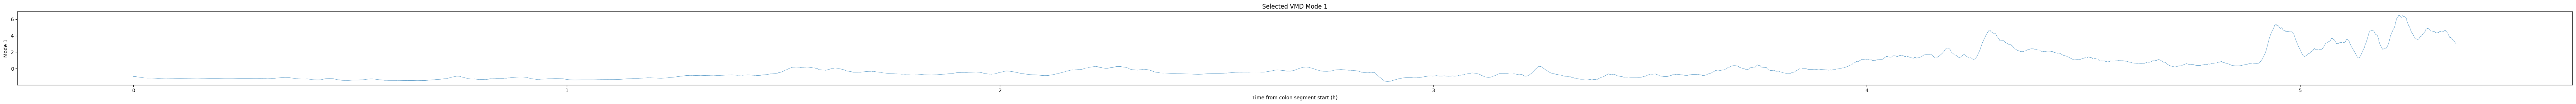

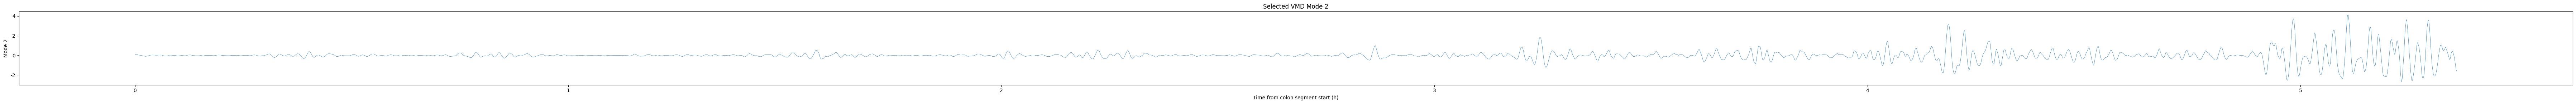

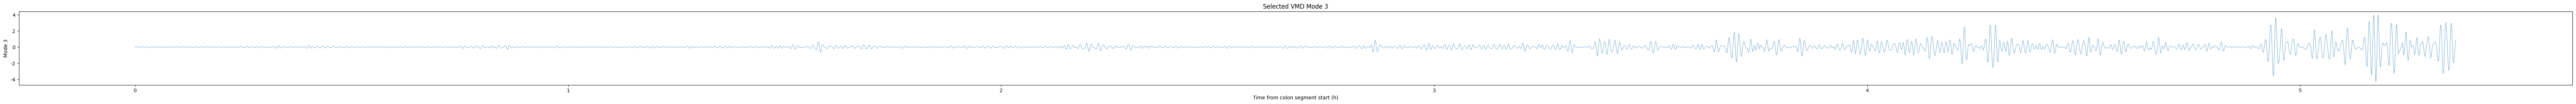

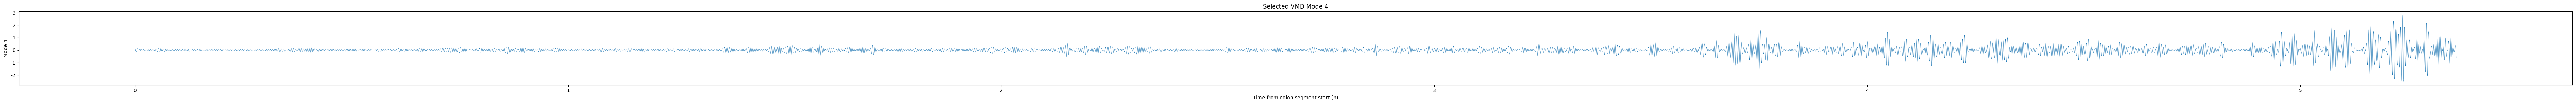

In [21]:
# ============================================================
# 10.1 Plot final selected modes
# ============================================================

time = df_out["Time"].values[:main_vmd_result.modes.shape[1]]
time_hours = (time - time[0]) / 3600.0

selected_modes = main_mode_summary.loc[main_mode_summary["Selected"], "Mode"].tolist()

for mode_number in selected_modes:
    idx = mode_number - 1
    plt.figure(figsize=(72, 3))
    plt.plot(time_hours, main_vmd_result.modes[idx], linewidth=0.5)
    plt.xlabel("Time from colon segment start (h)")
    plt.ylabel(f"Mode {mode_number}")
    plt.title(f"Selected VMD Mode {mode_number}")
    plt.tight_layout()
    plt.show()

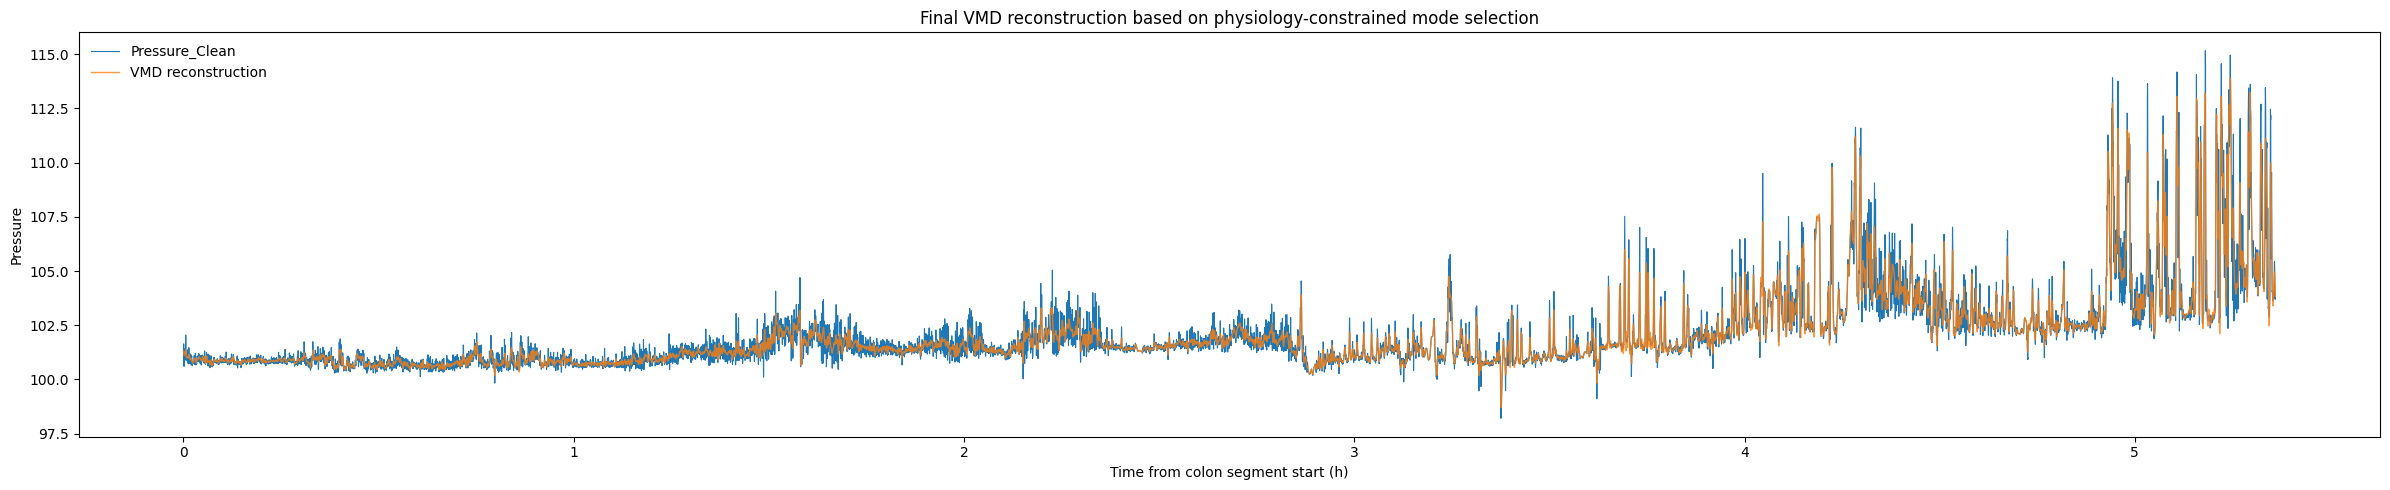

In [18]:
# ============================================================
# 10.2 Plot final VMD reconstruction
# ============================================================

reference = df_out["Pressure_Clean"].values
reference, reconstruction = baseline_align_reconstruction(reference, main_vmd_result.reconstructed)

time = df_out["Time"].values[:len(reference)]
time_hours = (time - time[0]) / 3600.0

plt.figure(figsize=(24, 5))
plt.plot(time_hours, reference, label="Pressure_Clean", linewidth=0.8)
plt.plot(time_hours, reconstruction, label="VMD reconstruction", linewidth=1.0, alpha=0.8)
plt.xlabel("Time from colon segment start (h)")
plt.ylabel("Pressure")
plt.title("Final VMD reconstruction based on physiology-constrained mode selection")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 11. Export paper-ready tables

导出的表格建议用于论文结果部分或补充材料。

In [19]:
# ============================================================
# 11. Export paper-ready tables
# ============================================================

preprocessing_summary.to_csv(OUTPUT_DIR / "preprocessing_summary.csv", index=False)
noise_reduction_summary.to_csv(OUTPUT_DIR / "noise_reduction_summary.csv", index=False)
preclean_event_metrics.to_csv(OUTPUT_DIR / "preclean_event_preservation_metrics.csv", index=False)
clean_event_metrics.to_csv(OUTPUT_DIR / "clean_event_preservation_metrics.csv", index=False)
semi_report["summary"].to_csv(OUTPUT_DIR / "semisynthetic_validation_summary.csv", index=False)
vmd_input_mode_comparison.to_csv(OUTPUT_DIR / "vmd_input_mode_comparison.csv", index=False)
vmd_input_reconstruction_comparison.to_csv(OUTPUT_DIR / "vmd_input_reconstruction_comparison.csv", index=False)
vmd_input_event_comparison.to_csv(OUTPUT_DIR / "vmd_input_event_comparison.csv", index=False)
mode_ablation_comparison.to_csv(OUTPUT_DIR / "mode_ablation_comparison.csv", index=False)
vmd_param_search_result.to_csv(OUTPUT_DIR / "vmd_parameter_search_result.csv", index=False)
selected_parameter_summary.to_csv(OUTPUT_DIR / "selected_parameter_summary.csv", index=False)
main_mode_summary.to_csv(OUTPUT_DIR / "final_vmd_mode_summary.csv", index=False)

print(f"All tables exported to: {OUTPUT_DIR.resolve()}")

All tables exported to: D:\a_work\课题组实验数据处理\新预处理\paper_outputs


## 12. Paper writing notes

可直接用于论文的关键表述：

**English:** Although `Pressure_Clean` underwent adaptive smoothing, its physiological event preservation metrics remained comparable to those of `Pressure_Preclean`, while achieving improved VMD reconstruction fidelity.

**中文：** 尽管 `Pressure_Clean` 经历了自适应平滑处理，但其生理事件保留指标与 `Pressure_Preclean` 基本一致，同时获得了更好的 VMD 重构性能。

**English:** Although lower decomposition levels occasionally yielded slightly lower reconstruction error, moderate decomposition complexity (`K=6`) provided richer multiscale physiological dynamics, which was more suitable for subsequent phase-space reconstruction and disease characterization.

**中文：** 尽管较低分解层数有时能够获得略低的重构误差，但中等分解复杂度（`K=6`）能够保留更丰富的多尺度生理动力学信息，更适合后续相空间重构与疾病特征表征。